# Experiment-1 (Part Two)

**Implementation of simple linear regression (txt file)**

In [142]:
# Import all the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [143]:
# Loading the dataset
df=pd.read_fwf(r"C:\Users\Yug\Downloads\SALES.txt", colspecs='infer', header=None)
df.head()

,0,1
0,12.0,15.0
1,20.5,16.0
2,21.0,18.0
3,15.5,27.0
4,15.3,21.0


In [144]:
# Shape of the dataframe
df.shape

(36, 2)

In [145]:
# Rename columns of the dataframe
df.columns=['Advertising', 'Sales']
df.head()

,Advertising,Sales
0,12.0,15.0
1,20.5,16.0
2,21.0,18.0
3,15.5,27.0
4,15.3,21.0


In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Advertising  36 non-null     float64
 1   Sales        36 non-null     float64
dtypes: float64(2)
memory usage: 708.0 bytes


In [147]:
# Extracting X(Advertising) and Y(Sales)
x=df['Advertising'].values
y=df['Sales'].values

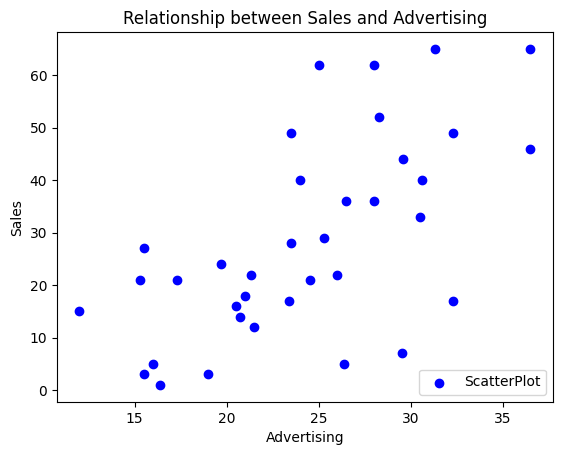

In [148]:
# Visualisation (Scatterplot)
plt.scatter(x, y, color='blue', label='ScatterPlot')
plt.title('Relationship between Sales and Advertising')
plt.xlabel('Advertising')
plt.ylabel('Sales')
plt.legend(loc=4)

In [149]:
# Checking shapes
print(x.shape)
print(y.shape)

(36,)
(36,)


In [150]:
# Reshape the variables
x=x.reshape(-1,1)
y=y.reshape(-1,1)
print(x.shape)
print(y.shape)

(36, 1)
(36, 1)


In [151]:
# Splitting the dataset (80-20)
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(28, 1)
(28, 1)
(8, 1)
(8, 1)


In [152]:
# Fitting linear model into training set
lm=LinearRegression()
lm.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [153]:
# Predict test set results
y_pred=lm.predict(x_test)
y_pred

array([[14.80256613],
       [29.59488723],
       [31.58935749],
       [34.58106288],
       [48.20994299],
       [39.56723853],
       [23.27906474],
       [16.29841883]])

In [154]:
# Compare with actual Y results
y_test

array([[ 1.],
       [29.],
       [36.],
       [52.],
       [46.],
       [65.],
       [12.],
       [21.]])

In [156]:
# Compute model slope and intercept
a=lm.coef_
b=lm.intercept_
print("Estimated Model Slope: ",a)
print("Estimated Intercept: ",b)

Estimated Model Slope:  [[1.66205855]]
Estimated Intercept:  [-12.45519409]


In [157]:
# Compute RMSE
mse=mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mse)
print("RMSE Value: {:.4f}".format(rmse))

RMSE Value: 12.8198


In [159]:
# Compute R2 Score
print("R2 Score: {:.4f}".format(r2_score(y_test, y_pred)))

R2 Score: 0.5875


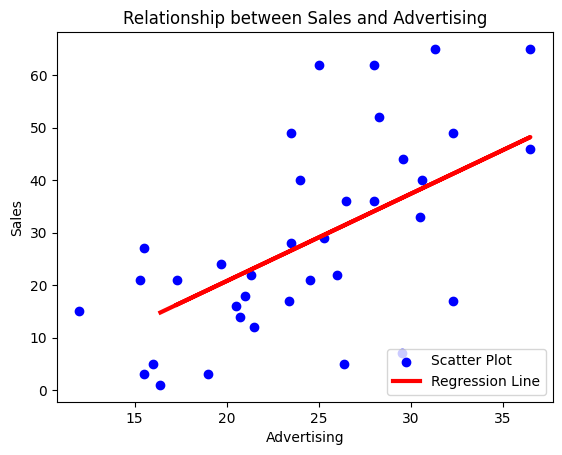

In [164]:
# Visualise the results
plt.scatter(x, y, color='blue', label='Scatter Plot')
plt.plot(x_test, y_pred, color='red', linewidth=3, label='Regression Line')
plt.title('Relationship between Sales and Advertising')
plt.xlabel('Advertising')
plt.ylabel('Sales')
plt.legend(loc=4)

In [169]:
# Check for overfitting or underfitting
print("Training set score: {:.4f}".format(lm.score(x_train, y_train)))
print("Testing set score: {:.4f}".format(lm.score(x_test, y_test)))

Training set score: 0.3068
Testing set score: 0.5875


**We have got an underfitted curve**